# Actividad 4.1 — Modelado estadístico para Big Data
## Covertype — modelado no supervisado

**Pregunta:** ¿Qué estructuras de agrupación pueden identificarse a partir de las características cartográficas y qué tan confiables y útiles resultan los grupos obtenidos?

**Unidad de análisis:** una celda territorial de 30 × 30 metros.

`Cover_Type` se separa desde el inicio y solo se usa al final para validación externa.

## 1. Librerías y configuración

In [1]:
import os, gc, time, warnings, itertools, shutil
import importlib.metadata as md_pkg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.datasets import fetch_covtype
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("figures", exist_ok=True)

print("Configuración lista.")

Configuración lista.


## 2. Carga de datos y separación de `Cover_Type`

In [2]:
cov = fetch_covtype(as_frame=False)

feature_names = list(getattr(cov, "feature_names", []))
if len(feature_names) != 54:
    quantitative_names = [
        "Elevation","Aspect","Slope",
        "Horizontal_Distance_To_Hydrology",
        "Vertical_Distance_To_Hydrology",
        "Horizontal_Distance_To_Roadways",
        "Hillshade_9am","Hillshade_Noon","Hillshade_3pm",
        "Horizontal_Distance_To_Fire_Points"
    ]
    feature_names = (
        quantitative_names
        + [f"Wilderness_Area_{i}" for i in range(4)]
        + [f"Soil_Type_{i}" for i in range(40)]
    )

X = cov.data.astype(np.float32, copy=False)
y = np.asarray(cov.target).ravel().astype(np.int8, copy=False)

del cov
gc.collect()

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables predictoras: {X.shape[1]}")
print(f"Memoria de X: {X.nbytes / 1024**2:.2f} MB")

Observaciones: 581,012
Variables predictoras: 54
Memoria de X: 119.68 MB


## 3. Diagnóstico inicial

In [3]:
N_QUANT = 10
N_BINARY = X.shape[1] - N_QUANT

n_missing = int(np.isnan(X).sum())

df_tmp = pd.DataFrame(X, columns=feature_names, copy=False)
n_duplicates = int(df_tmp.duplicated().sum())
del df_tmp
gc.collect()

diagnostico = pd.DataFrame({
    "Indicador": [
        "Observaciones","Variables predictoras","Variables cuantitativas",
        "Variables binarias","Valores faltantes","Filas duplicadas",
        "Tipo de dato de X","Memoria de X (MB)"
    ],
    "Resultado": [
        f"{X.shape[0]:,}", X.shape[1], N_QUANT, N_BINARY,
        n_missing, n_duplicates, str(X.dtype),
        round(X.nbytes / 1024**2, 2)
    ]
})

diagnostico

,Indicador,Resultado
0,Observaciones,"581,012"
1,Variables predictoras,54
2,Variables cuantitativas,10
3,Variables binarias,44
4,Valores faltantes,0
5,Filas duplicadas,0
6,Tipo de dato de X,float32
7,Memoria de X (MB),119.68


## 4. Preparación de datos

Las 10 variables cuantitativas se estandarizan con `StandardScaler`.  
Las 44 variables binarias se conservan como 0/1.

In [4]:
scaler = StandardScaler()
t0 = time.perf_counter()

X[:, :N_QUANT] = scaler.fit_transform(
    X[:, :N_QUANT]
).astype(np.float32)

tiempo_preparacion = time.perf_counter() - t0
memoria_referencia_mb = X.nbytes / 1024**2

print(f"Preparación terminada en {tiempo_preparacion:.2f} s")
print(f"Dimensiones de referencia: {X.shape}")
print(f"Memoria de referencia: {memoria_referencia_mb:.2f} MB")

Preparación terminada en 0.25 s
Dimensiones de referencia: (581012, 54)
Memoria de referencia: 119.68 MB


## 5. Incremental PCA

Se calculan los componentes necesarios para 90%, 95% y 99%.  
El umbral principal se fija en **90%**; después se hace una prueba de sensibilidad.

In [5]:
BATCH_PCA = 50_000

ipca = IncrementalPCA(
    n_components=X.shape[1],
    batch_size=BATCH_PCA
)

t0 = time.perf_counter()
ipca.fit(X)
tiempo_ajuste_pca = time.perf_counter() - t0

cumvar = np.cumsum(ipca.explained_variance_ratio_)

def componentes_para_umbral(umbral):
    return int(np.searchsorted(cumvar, umbral) + 1)

ncomp_90 = componentes_para_umbral(0.90)
ncomp_95 = componentes_para_umbral(0.95)
ncomp_99 = componentes_para_umbral(0.99)

ncomp_final = ncomp_90

print(f"Tiempo PCA incremental: {tiempo_ajuste_pca:.2f} s")
print(f"Componentes para 90%: {ncomp_90}")
print(f"Componentes para 95%: {ncomp_95}")
print(f"Componentes para 99%: {ncomp_99}")
print(f"Varianza final conservada: {cumvar[ncomp_final-1]:.4f}")

Tiempo PCA incremental: 2.83 s
Componentes para 90%: 10
Componentes para 95%: 14
Componentes para 99%: 26
Varianza final conservada: 0.9224


### 5.1 Varianza explicada acumulada — CORREGIDA a 90%

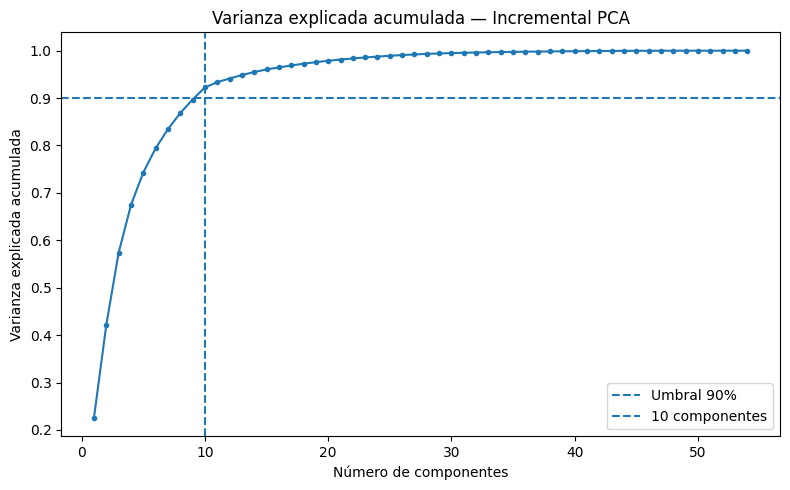

In [6]:
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(cumvar)+1), cumvar, marker="o", markersize=3)
plt.axhline(0.90, linestyle="--", label="Umbral 90%")
plt.axvline(ncomp_final, linestyle="--", label=f"{ncomp_final} componentes")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada — Incremental PCA")
plt.legend()
plt.tight_layout()
plt.savefig("figures/01_varianza_acumulada.png", dpi=160, bbox_inches="tight")
plt.show()

### 5.2 Variables con mayor contribución

In [7]:
filas = []
for i in range(min(5, ncomp_final)):
    cargas = ipca.components_[i]
    idx = np.argsort(np.abs(cargas))[-5:][::-1]
    for j in idx:
        filas.append({
            "Componente": f"PC{i+1}",
            "Variable": feature_names[j],
            "Carga": float(cargas[j]),
            "Carga_abs": float(abs(cargas[j]))
        })

tabla_cargas = pd.DataFrame(filas)
tabla_cargas

,Componente,Variable,Carga,Carga_abs
0,PC1,Hillshade_3pm,0.593068,0.593068
1,PC1,Aspect,0.499233,0.499233
2,PC1,Hillshade_9am,-0.470135,0.470135
3,PC1,Hillshade_Noon,0.359827,0.359827
4,PC1,Horizontal_Distance_To_Hydrology,0.104098,0.104098
5,PC2,Slope,0.509154,0.509154
6,PC2,Horizontal_Distance_To_Roadways,-0.406464,0.406464
7,PC2,Hillshade_Noon,-0.362799,0.362799
8,PC2,Elevation,-0.358884,0.358884
9,PC2,Horizontal_Distance_To_Fire_Points,-0.340747,0.340747


### 5.3 Transformación final por lotes

In [8]:
X_pca_final = np.empty(
    (X.shape[0], ncomp_final),
    dtype=np.float32
)

t0 = time.perf_counter()

for inicio in range(0, X.shape[0], BATCH_PCA):
    fin = min(inicio + BATCH_PCA, X.shape[0])
    X_pca_final[inicio:fin] = ipca.transform(
        X[inicio:fin]
    )[:, :ncomp_final].astype(np.float32, copy=False)

tiempo_transformacion_pca = time.perf_counter() - t0
memoria_pca_final_mb = X_pca_final.nbytes / 1024**2

comparacion_representaciones = pd.DataFrame({
    "Representación": ["Referencia sin reducción", "PCA 90%"],
    "Variables/componentes": [X.shape[1], X_pca_final.shape[1]],
    "Varianza conservada": [1.0, float(cumvar[ncomp_final-1])],
    "Memoria (MB)": [memoria_referencia_mb, memoria_pca_final_mb]
})

print(f"Transformación PCA terminada en {tiempo_transformacion_pca:.2f} s")
comparacion_representaciones

Transformación PCA terminada en 0.38 s


,Representación,Variables/componentes,Varianza conservada,Memoria (MB)
0,Referencia sin reducción,54,1.000000,119.684784
1,PCA 90%,10,0.922411,22.163849


## 6. MiniBatch K-Means con PCA 90%

Se evalúan `k = 2, 3, 4, 5, 6`, con tres semillas.  
Las métricas costosas usan la misma muestra reproducible de 5,000 registros.

In [9]:
K_VALUES = [2,3,4,5,6]
SEEDS = [42,123,2026]

rng = np.random.default_rng(RANDOM_STATE)
N_METRIC_SAMPLE = min(5000, X_pca_final.shape[0])
metric_idx = np.sort(
    rng.choice(X_pca_final.shape[0], size=N_METRIC_SAMPLE, replace=False)
)
X_eval_final = X_pca_final[metric_idx]

resultados_90 = []
labels_muestra_90 = {k: [] for k in K_VALUES}

for k in K_VALUES:
    for seed in SEEDS:
        modelo = MiniBatchKMeans(
            n_clusters=k, random_state=seed, batch_size=4096,
            n_init=1, max_iter=200, reassignment_ratio=0.01
        )

        t0 = time.perf_counter()
        modelo.fit(X_pca_final)
        tiempo_fit = time.perf_counter() - t0

        labels_eval = modelo.predict(X_eval_final)
        labels_muestra_90[k].append(labels_eval.copy())

        tamanos = np.bincount(modelo.labels_, minlength=k)

        resultados_90.append({
            "k": k,
            "seed": seed,
            "inercia": float(modelo.inertia_),
            "silhouette": float(silhouette_score(X_eval_final, labels_eval)),
            "davies_bouldin": float(davies_bouldin_score(X_eval_final, labels_eval)),
            "calinski_harabasz": float(calinski_harabasz_score(X_eval_final, labels_eval)),
            "tiempo_s": float(tiempo_fit),
            "tamano_min": int(tamanos.min()),
            "tamano_max": int(tamanos.max()),
            "tamanos_cluster": ", ".join(map(str, tamanos.tolist()))
        })

        del modelo, labels_eval
        gc.collect()

resultados_90_df = pd.DataFrame(resultados_90)
resultados_90_df.head(15)

,k,seed,inercia,silhouette,davies_bouldin,calinski_harabasz,tiempo_s,tamano_min,tamano_max,tamanos_cluster
0,2,42,4979636.00,0.204118,1.892359,1197.210327,0.109823,223665,357347,"357347, 223665"
1,2,123,5354220.00,0.204969,2.276951,760.788940,0.140181,149908,431104,"149908, 431104"
2,2,2026,5342668.00,0.181847,2.290565,789.257507,0.136036,174057,406955,"174057, 406955"
3,3,42,4539751.50,0.187123,1.828143,894.744019,0.137787,92200,302392,"302392, 186420, 92200"
4,3,123,4437638.00,0.182731,1.799987,993.689575,0.406970,89779,282660,"89779, 282660, 208573"
5,3,2026,4537303.50,0.165767,1.856621,900.442871,0.281029,72998,320449,"72998, 187565, 320449"
6,4,42,4137616.75,0.159060,1.743575,815.042053,0.226211,71044,263096,"263096, 165065, 81807, 71044"
7,4,123,4014013.75,0.179672,1.701706,900.082520,0.268196,85267,248558,"86818, 248558, 85267, 160369"
8,4,2026,4052870.00,0.151168,1.842910,867.094238,0.207208,58089,194788,"58089, 159634, 194788, 168501"
9,5,42,3702640.50,0.165182,1.645305,829.233826,0.258651,59230,184166,"184166, 139741, 67555, 59230, 130320"


### 6.1 Estabilidad y resumen por `k`

In [10]:
estabilidad_90 = []

for k in K_VALUES:
    aris = [
        adjusted_rand_score(a, b)
        for a, b in itertools.combinations(labels_muestra_90[k], 2)
    ]
    estabilidad_90.append({
        "k": k,
        "estabilidad_ARI_media": float(np.mean(aris)),
        "estabilidad_ARI_std": float(np.std(aris))
    })

estabilidad_90_df = pd.DataFrame(estabilidad_90)

resumen_90 = (
    resultados_90_df
    .groupby("k", as_index=False)
    .agg(
        inercia_media=("inercia","mean"),
        inercia_std=("inercia","std"),
        silhouette_media=("silhouette","mean"),
        silhouette_std=("silhouette","std"),
        davies_bouldin_media=("davies_bouldin","mean"),
        davies_bouldin_std=("davies_bouldin","std"),
        calinski_harabasz_media=("calinski_harabasz","mean"),
        calinski_harabasz_std=("calinski_harabasz","std"),
        tiempo_medio_s=("tiempo_s","mean")
    )
    .merge(estabilidad_90_df, on="k", how="left")
)

resumen_90.round(4)

,k,inercia_media,inercia_std,silhouette_media,silhouette_std,davies_bouldin_media,davies_bouldin_std,calinski_harabasz_media,calinski_harabasz_std,tiempo_medio_s,estabilidad_ARI_media,estabilidad_ARI_std
0,2,5.225508e+06,213009.7239,0.1970,0.0131,2.1533,0.2261,915.7523,244.1651,0.1287,0.1610,0.1438
1,3,4.504898e+06,58261.4388,0.1785,0.0113,1.8283,0.0283,929.6255,55.5542,0.2753,0.4772,0.0398
2,4,4.068167e+06,63205.3814,0.1633,0.0147,1.7627,0.0725,860.7396,42.8749,0.2339,0.3710,0.0299
3,5,3.693856e+06,17434.9722,0.1617,0.0077,1.6829,0.0917,842.5845,14.7788,0.2327,0.4879,0.0517
4,6,3.440465e+06,89086.0363,0.1548,0.0118,1.6875,0.1125,803.6592,40.6785,0.2698,0.5700,0.1002


### 6.2 Gráfica de métricas — CORREGIDA con resultados de PCA 90%

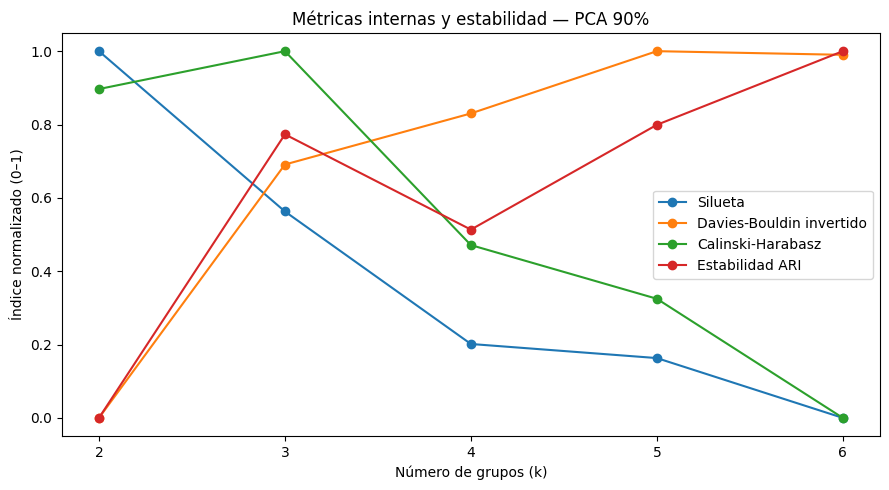

In [11]:
def minmax(s):
    s = np.asarray(s, dtype=float)
    r = s.max() - s.min()
    return np.ones_like(s) if r == 0 else (s - s.min()) / r

plot_metrics = pd.DataFrame({
    "k": resumen_90["k"],
    "Silueta": minmax(resumen_90["silhouette_media"]),
    "Davies-Bouldin invertido": 1 - minmax(resumen_90["davies_bouldin_media"]),
    "Calinski-Harabasz": minmax(np.log1p(resumen_90["calinski_harabasz_media"])),
    "Estabilidad ARI": minmax(resumen_90["estabilidad_ARI_media"])
})

plt.figure(figsize=(9,5))
for col in plot_metrics.columns[1:]:
    plt.plot(plot_metrics["k"], plot_metrics[col], marker="o", label=col)

plt.xlabel("Número de grupos (k)")
plt.ylabel("Índice normalizado (0–1)")
plt.title("Métricas internas y estabilidad — PCA 90%")
plt.xticks(K_VALUES)
plt.legend()
plt.tight_layout()
plt.savefig("figures/03_metricas_validacion.png", dpi=160, bbox_inches="tight")
plt.show()

### 6.3 Inercia — CORREGIDA con resultados de PCA 90%

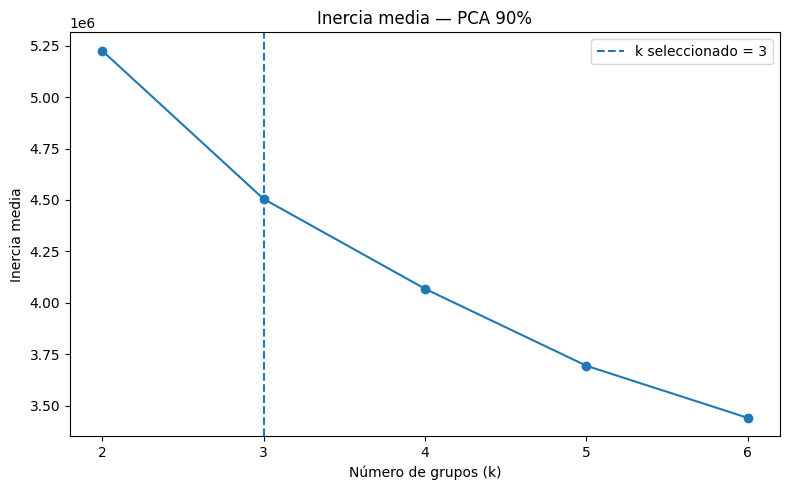

Configuración seleccionada: PCA 90% + k = 3


In [12]:
k_final = 3

plt.figure(figsize=(8,5))
plt.plot(resumen_90["k"], resumen_90["inercia_media"], marker="o")
plt.axvline(k_final, linestyle="--", label="k seleccionado = 3")
plt.xlabel("Número de grupos (k)")
plt.ylabel("Inercia media")
plt.title("Inercia media — PCA 90%")
plt.xticks(K_VALUES)
plt.legend()
plt.tight_layout()
plt.savefig("figures/02_inercia_k.png", dpi=160, bbox_inches="tight")
plt.show()

print("Configuración seleccionada: PCA 90% + k = 3")

### 6.4 Justificación de `k=3`

La elección se basa en evidencia conjunta. `k=3` mantiene una Silhouette relativamente alta, obtiene un Calinski-Harabasz favorable, mejora Davies-Bouldin respecto de `k=2` y presenta una estabilidad considerablemente mayor que `k=2`. No se selecciona con una sola métrica.

## 7. Sensibilidad al número de componentes

In [13]:
umbrales = {"90%": ncomp_90, "95%": ncomp_95, "99%": ncomp_99}
sensibilidad = []

for nombre, ncomp in umbrales.items():
    X_eval_umbral = ipca.transform(X[metric_idx])[:, :ncomp].astype(np.float32)

    modelo = MiniBatchKMeans(
        n_clusters=k_final, random_state=RANDOM_STATE,
        batch_size=4096, n_init=1, max_iter=200
    )

    t0 = time.perf_counter()

    if ncomp == ncomp_final:
        modelo.fit(X_pca_final)
    else:
        for inicio in range(0, X.shape[0], BATCH_PCA):
            fin = min(inicio + BATCH_PCA, X.shape[0])
            bloque = ipca.transform(X[inicio:fin])[:, :ncomp].astype(np.float32)
            modelo.partial_fit(bloque)

    tiempo_fit = time.perf_counter() - t0
    labels_eval = modelo.predict(X_eval_umbral)

    sensibilidad.append({
        "Umbral_varianza": nombre,
        "Componentes": ncomp,
        "Silhouette": silhouette_score(X_eval_umbral, labels_eval),
        "Davies_Bouldin": davies_bouldin_score(X_eval_umbral, labels_eval),
        "Calinski_Harabasz": calinski_harabasz_score(X_eval_umbral, labels_eval),
        "Tiempo_s": tiempo_fit
    })

    del modelo, labels_eval, X_eval_umbral
    gc.collect()

sensibilidad_df = pd.DataFrame(sensibilidad)
sensibilidad_df.round(4)

,Umbral_varianza,Componentes,Silhouette,Davies_Bouldin,Calinski_Harabasz,Tiempo_s
0,90%,10,0.1871,1.8281,894.744019,0.1829
1,95%,14,0.1186,2.2608,678.603394,0.5055
2,99%,26,0.1003,2.3466,598.609192,0.5486


## 8. Modelo final vs. referencia sin PCA

Se usa la misma `k=3`, semilla y muestra de evaluación en ambas configuraciones.

In [14]:
modelo_final = MiniBatchKMeans(
    n_clusters=k_final, random_state=RANDOM_STATE,
    batch_size=4096, n_init=1, max_iter=200
)

t0 = time.perf_counter()
modelo_final.fit(X_pca_final)
tiempo_final_reducido = time.perf_counter() - t0

labels_final = modelo_final.labels_.astype(np.int16, copy=True)
labels_eval_final = labels_final[metric_idx]

metricas_reducido = {
    "silhouette": silhouette_score(X_eval_final, labels_eval_final),
    "davies_bouldin": davies_bouldin_score(X_eval_final, labels_eval_final),
    "calinski_harabasz": calinski_harabasz_score(X_eval_final, labels_eval_final)
}

modelo_ref = MiniBatchKMeans(
    n_clusters=k_final, random_state=RANDOM_STATE,
    batch_size=4096, n_init=1, max_iter=200
)

t0 = time.perf_counter()
modelo_ref.fit(X)
tiempo_final_referencia = time.perf_counter() - t0

labels_eval_ref = modelo_ref.predict(X[metric_idx])

metricas_ref = {
    "silhouette": silhouette_score(X[metric_idx], labels_eval_ref),
    "davies_bouldin": davies_bouldin_score(X[metric_idx], labels_eval_ref),
    "calinski_harabasz": calinski_harabasz_score(X[metric_idx], labels_eval_ref)
}

comparacion_final = pd.DataFrame({
    "Configuración": ["Referencia sin PCA","PCA 90%"],
    "Dimensiones": [X.shape[1], X_pca_final.shape[1]],
    "Memoria_MB": [memoria_referencia_mb, memoria_pca_final_mb],
    "Tiempo_ajuste_KMeans_s": [tiempo_final_referencia, tiempo_final_reducido],
    "Silhouette": [metricas_ref["silhouette"], metricas_reducido["silhouette"]],
    "Davies_Bouldin": [metricas_ref["davies_bouldin"], metricas_reducido["davies_bouldin"]],
    "Calinski_Harabasz": [metricas_ref["calinski_harabasz"], metricas_reducido["calinski_harabasz"]]
})

comparacion_final.round(4)

,Configuración,Dimensiones,Memoria_MB,Tiempo_ajuste_KMeans_s,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,Referencia sin PCA,54,119.6848,0.3337,0.1438,1.9999,808.027405
1,PCA 90%,10,22.1638,0.1375,0.1871,1.8281,894.744019


## 9. Validación externa con `Cover_Type`

In [15]:
ari_externo = adjusted_rand_score(y, labels_final)
nmi_externo = normalized_mutual_info_score(y, labels_final)

validacion_externa = pd.DataFrame({
    "Métrica externa": ["Adjusted Rand Index","Normalized Mutual Information"],
    "Valor": [ari_externo, nmi_externo]
})

validacion_externa.round(4)

,Métrica externa,Valor
0,Adjusted Rand Index,0.0023
1,Normalized Mutual Information,0.0147


## 10. Visualización bidimensional

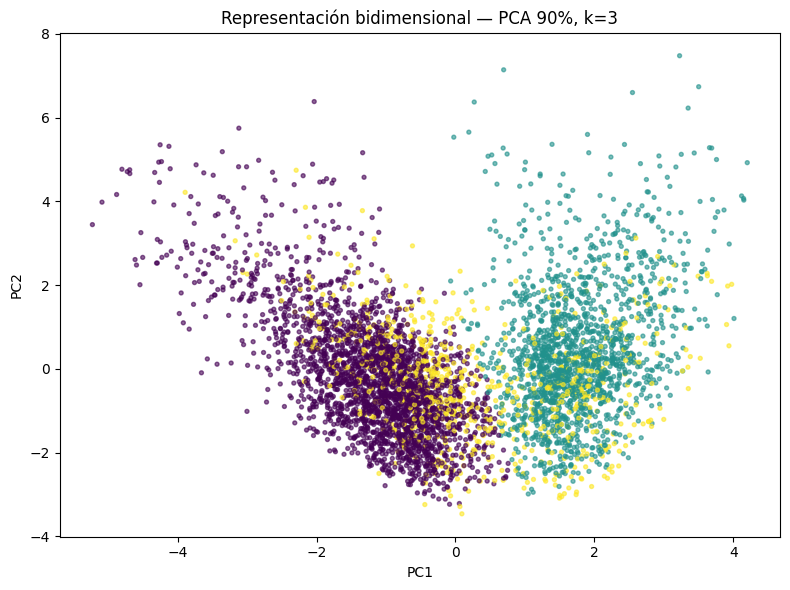

In [16]:
N_PLOT = min(5000, X_pca_final.shape[0])
rng_plot = np.random.default_rng(RANDOM_STATE)
plot_idx = np.sort(
    rng_plot.choice(X_pca_final.shape[0], size=N_PLOT, replace=False)
)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca_final[plot_idx,0], X_pca_final[plot_idx,1],
    c=labels_final[plot_idx], s=8, alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Representación bidimensional — PCA 90%, k=3")
plt.tight_layout()
plt.savefig("figures/05_representacion_2d.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Caracterización de los grupos con variables originales

In [17]:
for nombre in ["modelo_ref","labels_eval_ref","X_eval_final"]:
    if nombre in globals():
        del globals()[nombre]
gc.collect()

cov_perfiles = fetch_covtype(as_frame=False)
X_original = cov_perfiles.data.astype(np.float32, copy=False)
del cov_perfiles
gc.collect()

n_clusters = k_final
n_features = X_original.shape[1]

sumas = np.zeros((n_clusters,n_features), dtype=np.float64)
conteos = np.zeros(n_clusters, dtype=np.int64)

suma_global_q = np.zeros(N_QUANT, dtype=np.float64)
suma2_global_q = np.zeros(N_QUANT, dtype=np.float64)
n_global = 0
BATCH_PROFILE = 50_000

for inicio in range(0, X_original.shape[0], BATCH_PROFILE):
    fin = min(inicio+BATCH_PROFILE, X_original.shape[0])
    xb = X_original[inicio:fin]
    lb = labels_final[inicio:fin]

    suma_global_q += xb[:,:N_QUANT].sum(axis=0)
    suma2_global_q += np.square(xb[:,:N_QUANT], dtype=np.float64).sum(axis=0)
    n_global += xb.shape[0]

    for c in range(n_clusters):
        mask = lb == c
        if mask.any():
            sumas[c] += xb[mask].sum(axis=0)
            conteos[c] += int(mask.sum())

perfiles = sumas / conteos[:,None]
media_global_q = suma_global_q / n_global
var_global_q = (suma2_global_q / n_global) - np.square(media_global_q)
std_global_q = np.sqrt(np.maximum(var_global_q, 1e-12))

perfiles_df = pd.DataFrame(perfiles, columns=feature_names)
perfiles_df.insert(0,"Cluster",np.arange(n_clusters))
perfiles_df.insert(1,"n",conteos)
perfiles_df.insert(2,"Porcentaje",conteos/conteos.sum()*100)

perfiles_df[["Cluster","n","Porcentaje"]].round(2)

,Cluster,n,Porcentaje
0,0,302392,52.05
1,1,186420,32.09
2,2,92200,15.87


### 11.1 Nombres descriptivos y tabla final de perfiles

In [18]:
z_perfiles_q = (perfiles[:,:N_QUANT] - media_global_q) / std_global_q

idx_elev = feature_names.index("Elevation")
idx_aspect = feature_names.index("Aspect")
idx_hydro = feature_names.index("Horizontal_Distance_To_Hydrology")

cluster_hidro = int(np.argmax(
    z_perfiles_q[:,idx_elev] + z_perfiles_q[:,idx_hydro]
))
restantes = [c for c in range(n_clusters) if c != cluster_hidro]
cluster_este = min(restantes, key=lambda c: perfiles[c,idx_aspect])
cluster_oeste = [c for c in restantes if c != cluster_este][0]

nombres_clusters = {
    cluster_este: "Orientación este y mayor iluminación matutina",
    cluster_oeste: "Orientación oeste y mayor iluminación vespertina",
    cluster_hidro: "Mayor elevación y alejamiento de hidrología"
}

cols_tabla = [
    "Elevation","Aspect","Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Horizontal_Distance_To_Fire_Points"
]

tabla_perfiles_final = perfiles_df[
    ["Cluster","n","Porcentaje"] + cols_tabla
].copy()

tabla_perfiles_final.insert(
    1, "Nombre_cluster",
    tabla_perfiles_final["Cluster"].map(nombres_clusters)
)

tabla_perfiles_final.round(2)

,Cluster,Nombre_cluster,n,Porcentaje,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points
0,0,Orientación este y mayor iluminación matutina,302392,52.05,2917.16,77.71,13.63,196.31,26.23,2269.36,2116.36
1,1,Orientación oeste y mayor iluminación vespertina,186420,32.09,2934.96,288.55,15.32,221.91,39.43,2345.11,1682.79
2,2,Mayor elevación y alejamiento de hidrología,92200,15.87,3147.18,142.59,13.20,605.31,126.77,2625.23,2135.47


### 11.2 Visualización de perfiles

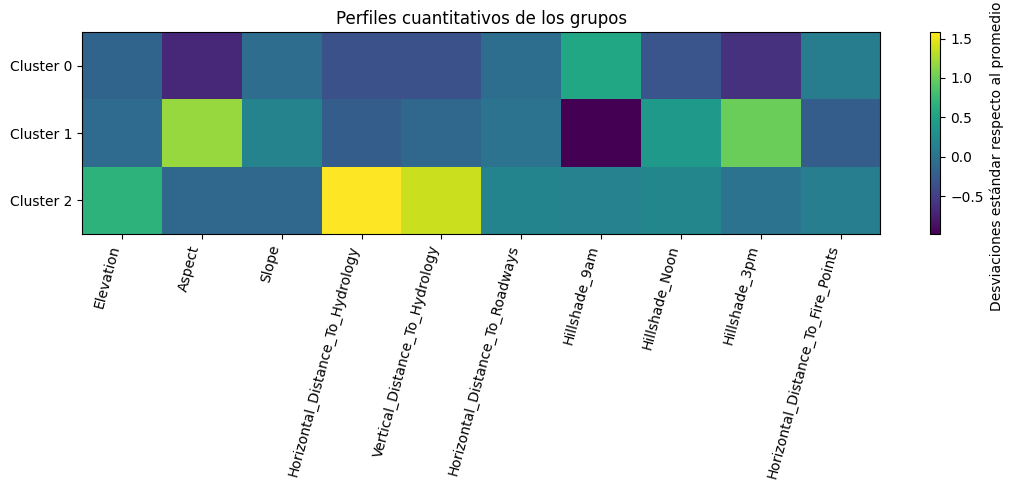

In [19]:
plt.figure(figsize=(11,5))
plt.imshow(z_perfiles_q, aspect="auto")
plt.colorbar(label="Desviaciones estándar respecto al promedio global")
plt.xticks(
    np.arange(N_QUANT),
    feature_names[:N_QUANT],
    rotation=75, ha="right"
)
plt.yticks(
    np.arange(n_clusters),
    [f"Cluster {i}" for i in range(n_clusters)]
)
plt.title("Perfiles cuantitativos de los grupos")
plt.tight_layout()
plt.savefig("figures/04_perfiles_clusters.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Resumen automático

In [20]:
mejor_fila_final = resumen_90.loc[
    resumen_90["k"] == k_final
].iloc[0]

resumen_resultados = {
    "k_seleccionado": k_final,
    "componentes_PCA": ncomp_final,
    "varianza_conservada": float(cumvar[ncomp_final-1]),
    "silhouette": float(metricas_reducido["silhouette"]),
    "davies_bouldin": float(metricas_reducido["davies_bouldin"]),
    "calinski_harabasz": float(metricas_reducido["calinski_harabasz"]),
    "estabilidad_ARI_media": float(mejor_fila_final["estabilidad_ARI_media"]),
    "ARI_externo": float(ari_externo),
    "NMI_externo": float(nmi_externo),
    "memoria_referencia_MB": float(memoria_referencia_mb),
    "memoria_PCA_MB": float(memoria_pca_final_mb),
    "tiempo_kmeans_referencia_s": float(tiempo_final_referencia),
    "tiempo_kmeans_PCA_s": float(tiempo_final_reducido)
}

pd.Series(resumen_resultados).to_frame("Resultado").round(4)

,Resultado
k_seleccionado,3.0000
componentes_PCA,10.0000
varianza_conservada,0.9224
silhouette,0.1871
davies_bouldin,1.8281
calinski_harabasz,894.7440
estabilidad_ARI_media,0.4772
ARI_externo,0.0023
NMI_externo,0.0147
memoria_referencia_MB,119.6848


## 13. Evaluación crítica automática — sin tiempos antiguos

In [21]:
reduccion_memoria_pct = (
    1 - memoria_pca_final_mb / memoria_referencia_mb
) * 100

display(Markdown(f'''
### Evaluación crítica

La configuración final utiliza **{ncomp_final} componentes**, que conservan **{cumvar[ncomp_final-1]*100:.2f}% de la varianza**, y MiniBatch K-Means con **k={k_final}**.

La memoria disminuyó de **{memoria_referencia_mb:.2f} MB** a **{memoria_pca_final_mb:.2f} MB**, una reducción aproximada de **{reduccion_memoria_pct:.1f}%**. El tiempo de ajuste de K-Means también fue menor con PCA en esta ejecución.

Las métricas internas fueron: Silhouette **{metricas_reducido["silhouette"]:.4f}**, Davies-Bouldin **{metricas_reducido["davies_bouldin"]:.4f}** y Calinski-Harabasz **{metricas_reducido["calinski_harabasz"]:.2f}**. Existe estructura de agrupamiento, aunque la separación no es alta.

La estabilidad media entre semillas fue **{mejor_fila_final["estabilidad_ARI_media"]:.4f}**, por lo que la solución debe considerarse de estabilidad moderada.

La concordancia externa con `Cover_Type` fue muy baja: ARI **{ari_externo:.4f}** y NMI **{nmi_externo:.4f}**. Por ello, los clusters describen patrones cartográficos y no deben interpretarse como una reproducción de los tipos conocidos de cobertura forestal.

Entre las limitaciones se encuentran la sensibilidad de K-Means a la inicialización, la superposición entre grupos, la pérdida parcial de interpretabilidad por PCA y la preferencia del algoritmo por grupos aproximadamente compactos.

Como validación adicional, convendría comparar con otro algoritmo de agrupamiento o repetir el análisis sobre diferentes submuestras.
'''))


### Evaluación crítica

La configuración final utiliza **10 componentes**, que conservan **92.24% de la varianza**, y MiniBatch K-Means con **k=3**.

La memoria disminuyó de **119.68 MB** a **22.16 MB**, una reducción aproximada de **81.5%**. El tiempo de ajuste de K-Means también fue menor con PCA en esta ejecución.

Las métricas internas fueron: Silhouette **0.1871**, Davies-Bouldin **1.8281** y Calinski-Harabasz **894.74**. Existe estructura de agrupamiento, aunque la separación no es alta.

La estabilidad media entre semillas fue **0.4772**, por lo que la solución debe considerarse de estabilidad moderada.

La concordancia externa con `Cover_Type` fue muy baja: ARI **0.0023** y NMI **0.0147**. Por ello, los clusters describen patrones cartográficos y no deben interpretarse como una reproducción de los tipos conocidos de cobertura forestal.

Entre las limitaciones se encuentran la sensibilidad de K-Means a la inicialización, la superposición entre grupos, la pérdida parcial de interpretabilidad por PCA y la preferencia del algoritmo por grupos aproximadamente compactos.

Como validación adicional, convendría comparar con otro algoritmo de agrupamiento o repetir el análisis sobre diferentes submuestras.


## 14. Generar `requirements.txt` y `README.md`

In [22]:
paquetes = ["numpy","pandas","scikit-learn","matplotlib"]

with open("requirements.txt","w",encoding="utf-8") as f:
    for paquete in paquetes:
        try:
            f.write(f"{paquete}=={md_pkg.version(paquete)}\n")
        except md_pkg.PackageNotFoundError:
            pass

readme = f"""
# Actividad 4.1 — Modelado estadístico para Big Data

## Pregunta de análisis
¿Qué estructuras de agrupación pueden identificarse a partir de las características cartográficas y qué tan confiables y útiles resultan los grupos obtenidos?

## Fuente de datos
Covertype, UCI Machine Learning Repository.
https://archive.ics.uci.edu/dataset/31/covertype

## Unidad de análisis
Cada observación representa una celda territorial de 30 × 30 metros.

## Metodología
1. Separación de `Cover_Type`.
2. Diagnóstico de datos.
3. Estandarización de 10 variables cuantitativas y conservación de 44 binarias en 0/1.
4. Referencia sin reducción.
5. Incremental PCA con umbral principal de 90%.
6. Sensibilidad con 90%, 95% y 99%.
7. MiniBatch K-Means con k = {K_VALUES} y semillas {SEEDS}.
8. Evaluación con inercia, Silhouette, Davies-Bouldin, Calinski-Harabasz y estabilidad.
9. Comparación con la referencia.
10. Validación externa posterior con `Cover_Type`.
11. Caracterización de clusters con variables originales.

## Configuración final
- PCA: {ncomp_final} componentes.
- Varianza conservada: {cumvar[ncomp_final-1]*100:.2f}%.
- k = {k_final}.
- Algoritmo: MiniBatch K-Means.

## Resultados principales
- Silhouette: {metricas_reducido["silhouette"]:.4f}
- Davies-Bouldin: {metricas_reducido["davies_bouldin"]:.4f}
- Calinski-Harabasz: {metricas_reducido["calinski_harabasz"]:.2f}
- Estabilidad ARI media: {mejor_fila_final["estabilidad_ARI_media"]:.4f}
- ARI externo: {ari_externo:.4f}
- NMI externo: {nmi_externo:.4f}

## Comparación con referencia
- Memoria sin PCA: {memoria_referencia_mb:.2f} MB
- Memoria con PCA: {memoria_pca_final_mb:.2f} MB
- Tiempo K-Means sin PCA: {tiempo_final_referencia:.4f} s
- Tiempo K-Means con PCA: {tiempo_final_reducido:.4f} s

## Caracterización
{chr(10).join([f"- Cluster {c}: {nombres_clusters[c]}." for c in sorted(nombres_clusters)])}

Los nombres describen perfiles cartográficos y no representan categorías naturales ni tipos definitivos de cobertura forestal.

## Evaluación crítica
La solución presenta estructura interna, pero separación y estabilidad moderadas. La concordancia con `Cover_Type` es muy baja, por lo que no debe usarse como clasificación o sustituto de la variable conocida.

## Reproducción
1. Abrir `notebooks/actividad_4_1_modelado.ipynb`.
2. Instalar `requirements.txt`.
3. Ejecutar las celdas en orden.
4. Las figuras se generan en `figures/`.

## Referencia
Blackard, J. (1998). *Covertype* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C50K5N
"""

with open("README.md","w",encoding="utf-8") as f:
    f.write(readme.strip())

print("Archivos generados:")
print("- README.md")
print("- requirements.txt")
print("- figures/")

Archivos generados:
- README.md
- requirements.txt
- figures/


## 15. Comprimir figuras para descargarlas

In [23]:
shutil.make_archive("figures","zip","figures")
print("figures.zip creado.")

figures.zip creado.
